In [1]:
import pandas as pd


df = pd.read_csv('Imdb Movies Dataset.csv', on_bad_lines='skip')
df_aux = df.copy()

df.head(10)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,...,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,7/15/2010,825532764,148,False,160000000,...,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,11/5/2014,701729206,169,False,165000000,...,en,Interstellar,The adventures of a group of explorers who mak...,140.241,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,7/16/2008,1004558444,152,False,185000000,...,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,12/15/2009,2923706026,162,False,237000000,...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,4/25/2012,1518815515,143,False,220000000,...,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."
5,293660,Deadpool,7.606,28894,Released,2/9/2016,783100000,108,False,58000000,...,en,Deadpool,The origin story of former Special Forces oper...,72.735,Witness the beginning of a happy ending.,"Action, Adventure, Comedy","20th Century Fox, The Donners' Company, Genre ...",United States of America,English,"superhero, anti hero, mercenary, based on comi..."
6,299536,Avengers: Infinity War,8.255,27713,Released,4/25/2018,2052415039,149,False,300000000,...,en,Avengers: Infinity War,As the Avengers and their allies have continue...,154.340,An entire universe. Once and for all.,"Adventure, Action, Science Fiction",Marvel Studios,United States of America,"English, Xhosa","sacrifice, magic, superhero, based on comic, s..."
7,550,Fight Club,8.438,27238,Released,10/15/1999,100853753,139,False,63000000,...,en,Fight Club,A ticking-time-bomb insomniac and a slippery s...,69.498,Mischief. Mayhem. Soap.,Drama,"Regency Enterprises, Fox 2000 Pictures, Taurus...",United States of America,English,"dual identity, rage and hate, based on novel o..."
8,118340,Guardians of the Galaxy,7.906,26638,Released,7/30/2014,772776600,121,False,170000000,...,en,Guardians of the Galaxy,"Light years from Earth, 26 years after being a...",33.255,All heroes start somewhere.,"Action, Science Fiction, Adventure",Marvel Studios,United States of America,English,"spacecraft, based on comic, space, orphan, adv..."
9,680,Pulp Fiction,8.488,25893,Released,9/10/1994,213900000,154,False,8500000,...,en,Pulp Fiction,"A burger-loving hit man, his philosophical par...",74.862,Just because you are a character doesn't mean ...,"Thriller, Crime","Miramax, A Band Apart, Jersey Films",United States of America,"English, Spanish, French","drug dealer, boxer, massage, stolen money, bri..."


In [2]:
# Exibe os nomes e tipos de dados das colunas da tabela
df.dtypes

id                        int64
title                    object
vote_average            float64
vote_count                int64
status                   object
release_date             object
revenue                   int64
runtime                   int64
adult                      bool
budget                    int64
imdb_id                  object
original_language        object
original_title           object
overview                 object
popularity              float64
tagline                  object
genres                   object
production_companies     object
production_countries     object
spoken_languages         object
keywords                 object
dtype: object

**Cluterização**
---

In [ ]:
import pandas as pd
import numpy as np

features = ['popularity', 'vote_average', 'vote_count', 'runtime']
df_clustering = df_aux[features].copy()

df_clustering.replace({'runtime': 0}, np.nan, inplace=True)

df_clustering = df_clustering.dropna()

print(f'Total de registros para clusterização: {len(df_clustering)}')
display(df_clustering.head())

Total de registros para clusterização (sem budget): 258269


,popularity,vote_average,vote_count,runtime
0,83.952,8.364,34495,148
1,140.241,8.417,32571,169
2,130.643,8.512,30619,152
3,79.932,7.573,29815,162
4,98.082,7.710,29166,143


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)

print('Dados escalonados com sucesso.')

Dados escalonados com sucesso.


In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_result = df_aux.loc[df_clustering.index].copy()
df_result['cluster'] = clusters

print('Distribuição por Cluster:')
print(df_result['cluster'].value_counts())

Distribuição por Cluster:
cluster
1    157067
0    100203
3       979
2        20
Name: count, dtype: int64


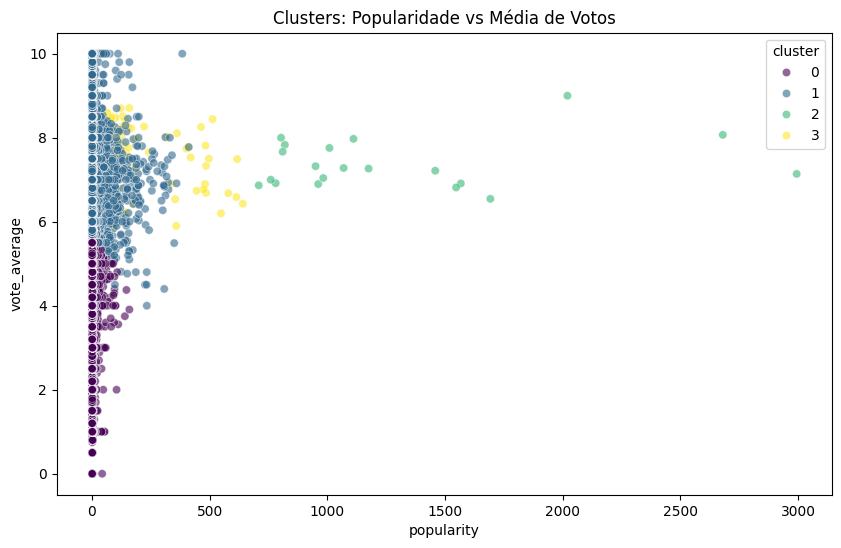

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_result, x='popularity', y='vote_average', hue='cluster', palette='viridis', alpha=0.6)
plt.title('Clusters: Popularidade vs Média de Votos')
plt.show()


In [ ]:
print('\n--- Perfil dos Clusters (Médias) ---')
display(df_result.groupby('cluster')[features].mean())


--- Perfil dos Clusters (Médias) ---


popularity         vote_average           vote_count          \
                mean   count         mean   count         mean   count   
cluster                                                                  
0           1.999964  100203     4.279523  100203    13.586579  100203   
1           3.470042  157067     7.051815  157067    71.749120  157067   
2        1295.066250      20     7.375350      20   929.400000      20   
3          55.902704     979     7.129847     979  8779.011236     979   

            runtime          
               mean   count  
cluster                      
0         77.213766  100203  
1         81.613171  157067  
2        117.200000      20  
3        160.751788     979

In [ ]:
cluster_3_movies = df_result[df_result['cluster'] == 3]
display(cluster_3_movies[['title', 'popularity', 'vote_average', 'vote_count', 'runtime']])

,title,popularity,vote_average,vote_count,runtime
825,Barbie,1069.340,7.279,5074,114
1110,Fast X,1175.267,7.265,3881,142
1799,Elemental,1008.942,7.757,2467,102
2129,Meg 2: The Trench,1567.273,6.912,2034,116
3873,Blue Beetle,2994.357,7.139,1023,128
4015,Talk to Me,1458.514,7.214,973,95
5048,Gran Turismo,2680.593,8.068,702,135
5835,Kandahar,708.536,6.866,575,119
6396,Sound of Freedom,1111.036,7.973,503,131
7919,The Nun II,1692.778,6.545,365,110
